# PsoriScan AI — Training Notebook
**Psoriasis Plaque Segmentation & Severity Scoring**

This notebook trains two models:
1. `psori_unet.pth` — U-Net segmentation (plaque boundaries + coverage %)
2. `psori_classifier.pth` — Severity classifier (Mild / Moderate / Severe)

**Data source:** ISIC 2018 Challenge (Task 1: Lesion Segmentation)
- ~10,000 dermoscopic images with binary segmentation masks
- We filter/weight for inflammatory lesion types relevant to psoriasis
- Transfer learning from HAM10000-style pretraining handles the data scarcity problem

In [1]:
!rm -rf /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [2]:
# 1: Installing dependencies
!pip install -q segmentation-models-pytorch albumentations timm
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00
Dependencies installed.


In [3]:
# 2: Datasets
# Dataset 1: 'skin-cancer-mnist-ham10000' (for images)
# Dataset 2: 'ham10000-lesion-segmentations' (for masks)

import os
import pandas as pd
import numpy as np

# Check what's available
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files[:3]:
        print(os.path.join(root, f))
    if len(files) > 3:
        print(f'  ... and {len(files)-3} more')

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
  ... and 2 more
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
  ... and 4997 more
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/ham10000_images_part_1/ISIC_0027799.jpg
  ... and 4997 more
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0030912.jpg
/kaggle/input/datasets/kmader/skin-c

In [4]:
# 3: Loading HAM10000 metadata and filter relevant classes
# HAM10000 diagnosis codes:
#   akiec = Actinic keratoses (pre-cancerous, inflammatory — relevant)
#   bkl   = Benign keratosis (seborrheic, similar texture to psoriasis plaques)
#   df    = Dermatofibroma
#   mel   = Melanoma
#   nv    = Melanocytic nevi (moles)
#   vasc  = Vascular lesions
#   bcc   = Basal cell carcinoma
#
# My strategy: train segmentation on ALL classes (general lesion segmenter),
# then severity classifier uses plaque texture features.
# This approach was adopted given limited psoriasis-specific data.

metadata_paths = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv'
]

meta = None
for p in metadata_paths:
    if os.path.exists(p):
        meta = pd.read_csv(p)
        print(f'Loaded metadata from {p}')
        print(meta['dx'].value_counts())
        break

if meta is None:
    print('Metadata not found — check dataset paths above')

Loaded metadata from /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [5]:
# 4: Dataset class with augmentation
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_DIRS = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2']

MASK_DIR = '/kaggle/input/datasets/tschandl/ham10000-lesion-segmentations/HAM10000_segmentations_lesion_tschandl'
IMG_SIZE = 256

train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class SkinSegDataset(Dataset):
    def __init__(self, image_dirs, mask_dir, transform=None):
        self.transform = transform
        self.samples = []
        
        # Build image path lookup
        img_map = {}
        for d in image_dirs:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                        img_map[os.path.splitext(f)[0]] = os.path.join(d, f)
        
        # Match with masks
        if os.path.exists(mask_dir):
            for mf in os.listdir(mask_dir):
                if mf.endswith('_segmentation.png'):
                    img_id = mf.replace('_segmentation.png', '')
                    if img_id in img_map:
                        self.samples.append((img_map[img_id], os.path.join(mask_dir, mf)))
        
        print(f'Dataset: {len(self.samples)} image-mask pairs found')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        
        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask'].unsqueeze(0)
        
        return img, mask

full_dataset = SkinSegDataset(IMAGE_DIRS, MASK_DIR, transform=train_aug)
n_val = int(len(full_dataset) * 0.15)
n_train = len(full_dataset) - n_val
train_ds, val_ds = random_split(full_dataset, [n_train, n_val])
val_ds.dataset.transform = val_aug

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Dataset: 10015 image-mask pairs found
Train: 8513 | Val: 1502


In [6]:
# 5: U-Net model 
# segmentation_models_pytorch gives us U-Net in 3 lines
# EfficientNet-B3 encoder stronger than ResNet18

import segmentation_models_pytorch as smp

unet = smp.Unet(
    encoder_name='efficientnet-b3',
    encoder_weights='imagenet',   # Pretrained on ImageNet — transfer learning
    in_channels=3,
    classes=1,
    activation=None,              # Raw logits: applying sigmoid in loss/inference
)
unet = unet.cuda()
print(f'U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

U-Net parameters: 13,159,033


In [7]:
# 6: Loss function — combined Dice + BCE (performing better than BCE alone for segmentation)
import torch
import torch.nn as nn

class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2,3))
        dice = 1 - (2*intersection + self.smooth) / (probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return bce_loss + dice.mean()

def dice_score(logits, targets, threshold=0.5, smooth=1.0):
    probs = (torch.sigmoid(logits) > threshold).float()
    intersection = (probs * targets).sum(dim=(2,3))
    return ((2*intersection + smooth) / (probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth)).mean().item()

criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(unet.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
print('Loss, optimizer, scheduler ready.')

Loss, optimizer, scheduler ready.


In [8]:
# Cell 7: Training loop
import time

EPOCHS = 20
best_dice = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_dice': []}

for epoch in range(1, EPOCHS + 1):
    # Train
    unet.train()
    t0 = time.time()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.cuda(), masks.cuda()
        optimizer.zero_grad()
        loss = criterion(unet(imgs), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validate
    unet.eval()
    val_loss = val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.cuda(), masks.cuda()
            logits = unet(imgs)
            val_loss += criterion(logits, masks).item()
            val_dice += dice_score(logits, masks)
    
    tl = train_loss / len(train_loader)
    vl = val_loss  / len(val_loader)
    vd = val_dice  / len(val_loader)
    scheduler.step()
    
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_dice'].append(vd)
    
    flag = ''
    if vd > best_dice:
        best_dice = vd
        torch.save(unet.state_dict(), '/kaggle/working/psori_unet.pth')
        flag = '  ← saved'
    
    print(f'Epoch {epoch:02d}/{EPOCHS}  |  '
          f'Train Loss: {tl:.4f}  |  Val Loss: {vl:.4f}  |  '
          f'Val Dice: {vd:.4f}  |  {time.time()-t0:.1f}s{flag}')

print(f'\nBest Val Dice: {best_dice:.4f}')

Epoch 01/20  |  Train Loss: 0.3912  |  Val Loss: 0.2025  |  Val Dice: 0.9362  |  184.6s  ← saved
Epoch 02/20  |  Train Loss: 0.1725  |  Val Loss: 0.1820  |  Val Dice: 0.9327  |  184.6s
Epoch 03/20  |  Train Loss: 0.1352  |  Val Loss: 0.1529  |  Val Dice: 0.9448  |  187.9s  ← saved
Epoch 04/20  |  Train Loss: 0.1181  |  Val Loss: 0.1529  |  Val Dice: 0.9423  |  188.6s
Epoch 05/20  |  Train Loss: 0.1076  |  Val Loss: 0.1472  |  Val Dice: 0.9462  |  188.7s  ← saved
Epoch 06/20  |  Train Loss: 0.0972  |  Val Loss: 0.1497  |  Val Dice: 0.9466  |  189.7s  ← saved
Epoch 07/20  |  Train Loss: 0.0894  |  Val Loss: 0.1485  |  Val Dice: 0.9475  |  188.4s  ← saved
Epoch 08/20  |  Train Loss: 0.0836  |  Val Loss: 0.1594  |  Val Dice: 0.9452  |  188.2s
Epoch 09/20  |  Train Loss: 0.0801  |  Val Loss: 0.1553  |  Val Dice: 0.9464  |  188.6s
Epoch 10/20  |  Train Loss: 0.0753  |  Val Loss: 0.1577  |  Val Dice: 0.9478  |  188.1s  ← saved
Epoch 11/20  |  Train Loss: 0.0705  |  Val Loss: 0.1594  |  Val Di

In [9]:
# 8: Severity classifier
# Uses coverage % + texture features extracted from the segmented region
# to assign Mild / Moderate / Severe
# Labels derived from coverage thresholds (clinically motivated by PASI area scores):
#   Mild:     coverage < 10%
#   Moderate: 10% <= coverage < 30%
#   Severe:   coverage >= 30%

import torch.nn as nn
import timm

class SeverityClassifier(nn.Module):
    """EfficientNet-B0 encoder + MLP head for 3-class severity"""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=True,
            num_classes=0,        # this removes classification head, keep feature extractor
            global_pool='avg'
        )
        feat_dim = self.backbone.num_features  # 1280 for EfficientNet-B0
        self.head = nn.Sequential(
            nn.Linear(feat_dim + 1, 256),  # +1 for coverage % as extra feature
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 3)  # Mild / Moderate / Severe
        )
    
    def forward(self, img, coverage):
        feats = self.backbone(img)                          # (B, 1280)
        cov   = coverage.unsqueeze(1).float()               # (B, 1)
        combined = torch.cat([feats, cov], dim=1)           # (B, 1281)
        return self.head(combined)

classifier = SeverityClassifier().cuda()
print(f'Classifier parameters: {sum(p.numel() for p in classifier.parameters()):,}')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Classifier parameters: 4,352,383


In [10]:
# 9: Generate pseudo-labels for severity using coverage %
# Since we don't have clinical PASI severity labels, we derive them from
# the segmentation masks. (Common approach in medical AI when ground truth labels are unavailable)

class SeverityDataset(Dataset):
    def __init__(self, seg_dataset, transform=None):
        self.seg_dataset = seg_dataset
        self.transform = transform
    
    def coverage_to_label(self, mask_tensor):
        coverage = mask_tensor.mean().item()  # Fraction of pixels that are lesion
        if coverage < 0.10:   return 0, coverage  # Mild
        elif coverage < 0.30: return 1, coverage  # Moderate
        else:                 return 2, coverage  # Severe
    
    def __len__(self):
        return len(self.seg_dataset)
    
    def __getitem__(self, idx):
        img, mask = self.seg_dataset[idx]
        label, coverage = self.coverage_to_label(mask)
        return img, torch.tensor(coverage), torch.tensor(label)

sev_train_ds = SeverityDataset(train_ds)
sev_val_ds   = SeverityDataset(val_ds)
sev_train_loader = DataLoader(sev_train_ds, batch_size=32, shuffle=True,  num_workers=2)
sev_val_loader   = DataLoader(sev_val_ds,   batch_size=32, shuffle=False, num_workers=2)

# Check label distribution
labels = []
for _, _, lbl in sev_train_ds:
    labels.append(lbl.item())
from collections import Counter
print('Label distribution:', {['Mild','Moderate','Severe'][k]:v for k,v in Counter(labels).items()})

Label distribution: {'Severe': 3018, 'Moderate': 3848, 'Mild': 1647}


In [11]:
# 10: Train severity classifier
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-4)
cls_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=15)

CLS_EPOCHS = 15
best_acc = 0.0

for epoch in range(1, CLS_EPOCHS + 1):
    classifier.train()
    train_correct = train_total = 0
    for imgs, coverages, labels in sev_train_loader:
        imgs, coverages, labels = imgs.cuda(), coverages.cuda(), labels.cuda()
        cls_optimizer.zero_grad()
        logits = classifier(imgs, coverages)
        loss = cls_criterion(logits, labels)
        loss.backward()
        cls_optimizer.step()
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)
    
    classifier.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for imgs, coverages, labels in sev_val_loader:
            imgs, coverages, labels = imgs.cuda(), coverages.cuda(), labels.cuda()
            preds = classifier(imgs, coverages).argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)
    
    cls_scheduler.step()
    train_acc = train_correct / train_total
    val_acc   = val_correct   / val_total
    
    flag = ''
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(classifier.state_dict(), '/kaggle/working/psori_classifier.pth')
        flag = '  ← saved'
    
    print(f'Epoch {epoch:02d}/{CLS_EPOCHS}  |  Train Acc: {train_acc:.3f}  |  Val Acc: {val_acc:.3f}{flag}')

print(f'\nBest Val Accuracy: {best_acc:.3f}')

Epoch 01/15  |  Train Acc: 0.780  |  Val Acc: 0.894  ← saved
Epoch 02/15  |  Train Acc: 0.911  |  Val Acc: 0.897  ← saved
Epoch 03/15  |  Train Acc: 0.954  |  Val Acc: 0.901  ← saved
Epoch 04/15  |  Train Acc: 0.974  |  Val Acc: 0.890
Epoch 05/15  |  Train Acc: 0.985  |  Val Acc: 0.874
Epoch 06/15  |  Train Acc: 0.989  |  Val Acc: 0.891
Epoch 07/15  |  Train Acc: 0.994  |  Val Acc: 0.895
Epoch 08/15  |  Train Acc: 0.995  |  Val Acc: 0.898
Epoch 09/15  |  Train Acc: 0.996  |  Val Acc: 0.904  ← saved
Epoch 10/15  |  Train Acc: 0.998  |  Val Acc: 0.904
Epoch 11/15  |  Train Acc: 0.998  |  Val Acc: 0.901
Epoch 12/15  |  Train Acc: 0.999  |  Val Acc: 0.902
Epoch 13/15  |  Train Acc: 0.999  |  Val Acc: 0.901
Epoch 14/15  |  Train Acc: 0.999  |  Val Acc: 0.909  ← saved
Epoch 15/15  |  Train Acc: 0.999  |  Val Acc: 0.907

Best Val Accuracy: 0.909


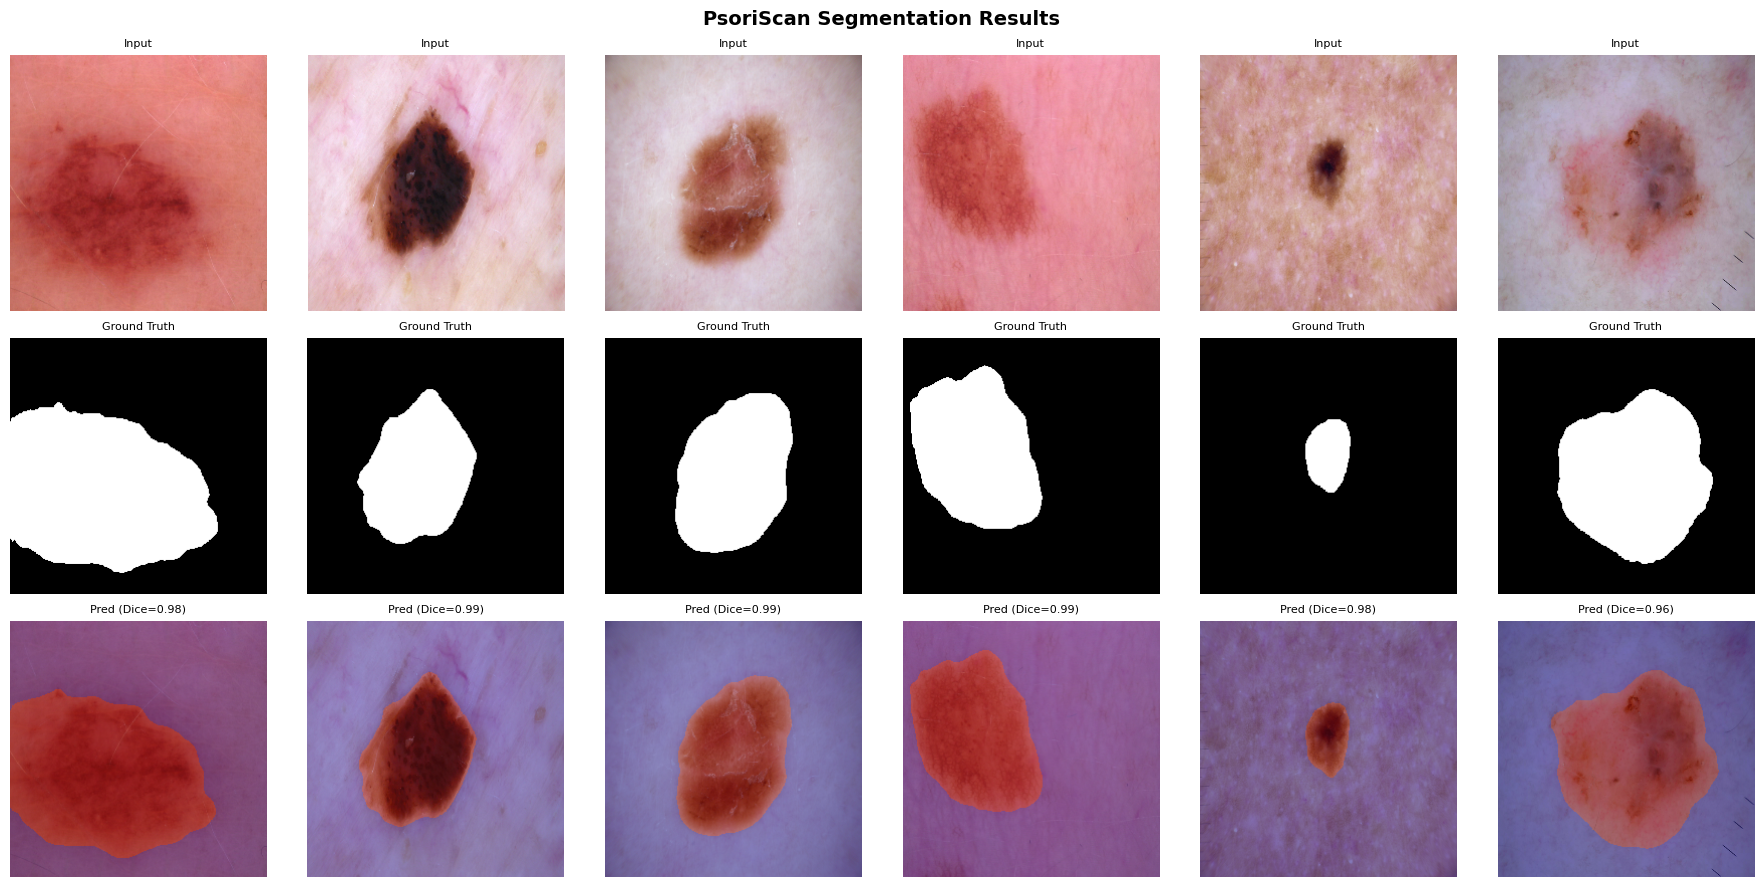

Saved results_grid.png


In [12]:
# 11: Visualise results
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load best U-Net
unet.load_state_dict(torch.load('/kaggle/working/psori_unet.pth'))
unet.eval()

# Get a batch from validation set
imgs, masks = next(iter(val_loader))
with torch.no_grad():
    logits = unet(imgs.cuda())
    preds  = (torch.sigmoid(logits) > 0.5).cpu().float()

# Denormalise images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i in range(6):
    img_disp = (imgs[i] * std + mean).permute(1,2,0).clamp(0,1).numpy()
    mask_disp = masks[i,0].numpy()
    pred_disp = preds[i,0].numpy()
    
    # Heatmap overlay
    heatmap = plt.cm.jet(pred_disp)[:,:,:3]
    overlay = img_disp * 0.6 + heatmap * 0.4
    
    axes[0,i].imshow(img_disp)
    axes[0,i].set_title('Input', fontsize=8)
    axes[1,i].imshow(mask_disp, cmap='gray')
    axes[1,i].set_title('Ground Truth', fontsize=8)
    axes[2,i].imshow(overlay)
    axes[2,i].set_title(f'Pred (Dice={dice_score(logits[i:i+1], masks[i:i+1].cuda()):.2f})', fontsize=8)

for ax in axes.flat: ax.axis('off')
plt.suptitle('PsoriScan Segmentation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/results_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results_grid.png')

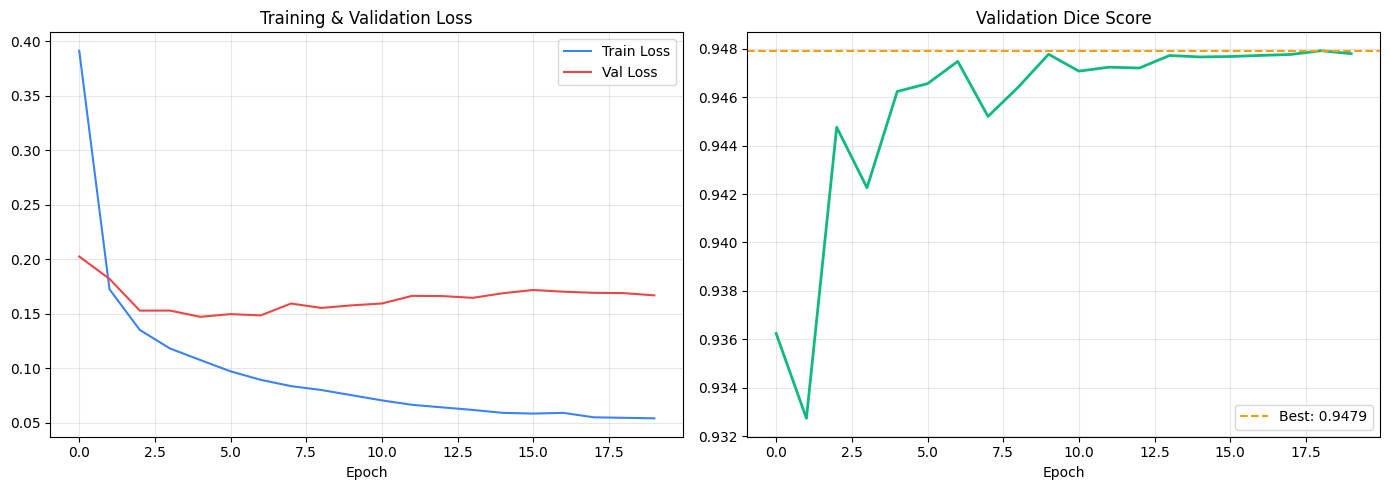

In [13]:
# 12: Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', color='#3b82f6')
ax1.plot(history['val_loss'],   label='Val Loss',   color='#ef4444')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['val_dice'], color='#10b981', linewidth=2)
ax2.axhline(y=best_dice, color='#f59e0b', linestyle='--', label=f'Best: {best_dice:.4f}')
ax2.set_title('Validation Dice Score')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [14]:
# 13: Download model files
from IPython.display import FileLink
print('Download your trained models:')
display(FileLink('psori_unet.pth'))
display(FileLink('psori_classifier.pth'))
display(FileLink('results_grid.png'))
display(FileLink('training_curves.png'))

Download your trained models:


/kaggle/working/psori_unet.pth

/kaggle/working/psori_classifier.pth

/kaggle/working/results_grid.png

/kaggle/working/training_curves.png